# V3 — 경기 흐름과 동일 랩 페이스

## 목표

관전 질문 하나를 따라갑니다. 최종 격차가 작았으면 경기 내내 비슷하게 빨랐을까요? 공식 시간 차이를 보고, 비교 가능한 랩 쌍을 고른 뒤 타이어 맥락을 붙입니다.

### 중요한 가정

SC 종료는 다음 선두 랩의 시작 후보입니다. 황색기 충돌 공지는 기록하고 보수적으로 처리합니다. 어느 섹터든 시간이 겹치면 제외하지만 해당 차량의 실제 영향이 확인된 것은 아닙니다. 타이어 인과 효과·연료·교통 보정은 없으며 페이스 요약은 모두 잠정 결과입니다.

## 준비

requirements.txt를 설치한 Python 커널을 선택하세요. 네트워크 요청 없이 저장된 자료를 읽습니다. 출처는 2026년 9월 26일 OpenF1 세션 11377이며 https://openf1.org/docs/와 생성된 원본 목록을 확인하세요.

In [1]:
from pathlib import Path
# 프로젝트 루트 또는 언어별 노트북 폴더에서 공통 자료 위치를 찾습니다.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'docs/analysis_design.json').exists() and (p / 'data/raw').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Open this notebook inside the baku-2026 project')


In [2]:
"""V3: 경기 흐름을 확인하고 후보 랩 쌍을 골라 페이스를 비교합니다.

저장된 OpenF1 원본만 읽습니다. SC 종료는 모두 경계 후보입니다.
운영 공지의 최종 검토나 인과적 결론을 확정하는 튜토리얼은 아닙니다.
"""
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib import font_manager

# ROOT is located in the preceding cell.
LANGUAGE = 'ko'
LABELS = {'gap_title': '러셀–베르스타펜 공식 시간 차이', 'gap_subtitle': '바쿠 2026 | 공식 시간 차이 표본 사용. SC 음영 끝은 경계 후보입니다.', 'gap_note': '출처: OpenF1 세션 11377. 결측은 채우지 않았습니다. 상단 피트 표시는 이벤트 시각만 나타냅니다.\n표시 높이는 시간 차이가 아니며, 피트레인 활동만으로 타이어 교체를 확정하지 않습니다.', 'pit_63': 'RUS 피트레인 기록', 'pit_3': 'VER 피트레인 기록', 'elapsed_minutes': '선두 첫 랩 시작 이후 경과 시간 (분)', 'gap_seconds': 'VER와 RUS의 시간 차이 (초)', 'pace_title': '후보 랩의 동일 랩타임 차이', 'pace_subtitle': '같은 랩의 VER - RUS | 양수 = 러셀이 빠름 | 시간 구간 기준 잠정 제외', 'pace_note': '두 선수 중 한 명이라도 SC·피트·재출발 후보·황색기 시간과 겹친 랩 쌍은 제외했습니다.\n연료·교통 보정은 없습니다. 재출발 경계와 충돌 공지 검토가 남아 있습니다.', 'BEFORE_FIRST_SC': '첫 SC 이전', 'AFTER_SECOND_RESTART': '두 번째 재출발 후보 이후', 'median': '중앙값', 'insufficient': '요약할 랩 쌍이 부족합니다', 'lap_number': '경기 랩', 'paired_difference': 'VER - RUS 랩타임 (초)', 'tyre_title': '두 선수의 타이어 사용 구간', 'tyre_subtitle': '구간의 시작·끝과 구간 시작 시 타이어 사용량. 사용량 단위는 랩입니다.', 'tyre_note': '출처: OpenF1 stints. 새 타이어 구간이 반드시 새 타이어를 뜻하지는 않습니다.\n이 자료만으로 독립적인 타이어 효과나 마모 효과를 분리할 수 없습니다.', 'MEDIUM': '미디엄', 'SOFT': '소프트', 'age': '시작 사용량', 'pending': '잠정 결과: 최종 페이스 결론 전 재출발 경계와 운영 공지 검토 항목을 확인해야 합니다.', 'learning_notes': '읽는 순서: 1. 공식 시간 차이와 운영 공지 → 2. 후보 동일 랩 페이스 → 3. 타이어 맥락.\nVER - RUS가 양수이면 해당 랩에서 러셀이 더 빨랐다는 뜻입니다.\n중앙값은 랩별 차이의 가운데 값, IQR은 가운데 50% 값의 범위입니다.\n제외 이유는 확인할 수 있지만 SC 경계와 충돌 공지 처리는 아직 잠정적입니다.\n황색기는 모든 섹터의 시간 겹침을 보수적으로 제외합니다. 해당 차량의 실제 영향이 확인된 것은 아닙니다.\n황색기 제외 여부와 경계 ±1초를 바꾸는 검사는 모든 경계가 정확하다는 증거가 아닙니다.\n타이어의 인과 효과·연료 보정 페이스·가상의 우승자는 추정하지 않습니다.'}
SESSION = 11377
PAIR = [63, 3]
MINIMUM_PAIRS = 5
TIMING_TOLERANCE_SECONDS = 1.0
GAP_TOLERANCE_SECONDS = 8.0
BLUE, GOLD, PINK = '#3569A8', '#B18B32', '#BB6588'




## 분석 단계

### 원본 로딩과 검증

In [3]:
def load_and_validate(root):
    """원본을 읽고 유일키·조인·시각·드라이버 식별을 확인합니다."""
    sources, manifest = {}, []
    for endpoint in ['laps', 'drivers', 'stints', 'pit', 'race_control',
                     'session_result', 'intervals', 'position', 'sessions']:
        path = root / 'data/raw' / f'{endpoint}_session_key-{SESSION}.json'
        body = path.read_bytes()
        records = json.loads(body)
        assert isinstance(records, list) and records, f'Empty source: {endpoint}'
        frame = pd.DataFrame(records)
        assert frame.session_key.eq(SESSION).all(), f'Wrong session: {endpoint}'
        sources[endpoint] = frame
        manifest.append({'file':str(path.relative_to(root)), 'rows':len(frame),
                         'sha256':hashlib.sha256(body).hexdigest(),
                         'url':f'https://api.openf1.org/v1/{endpoint}?session_key={SESSION}'})
    laps, drivers = sources['laps'], sources['drivers']
    assert not laps.duplicated(['session_key', 'driver_number', 'lap_number']).any()
    assert not drivers.duplicated(['session_key', 'driver_number']).any()
    results = sources['session_result'].merge(
        drivers[['session_key', 'driver_number', 'full_name', 'name_acronym', 'team_name']],
        on=['session_key','driver_number'], validate='one_to_one', how='left', indicator=True)
    assert results['_merge'].eq('both').all()
    top10 = results[results.position.between(1,10)].sort_values('position').drop(columns='_merge')
    assert len(top10) == 10
    positions = sources['position'].query('driver_number == 63')
    assert len(positions) and positions.position.eq(1).all(), 'Gap is not always to Russell'
    pair = laps[laps.driver_number.isin(PAIR)].copy()
    assert len(pair) == 102 and pair.groupby('driver_number').size().eq(51).all()
    assert pair.lap_duration.notna().all() and pair.lap_duration.gt(0).all()
    assert pair.is_pit_out_lap.notna().all(), 'Missing pit-out status needs review'
    pair = pair.sort_values(['driver_number', 'lap_number']).reset_index(drop=True)
    pair['start_utc'] = pd.to_datetime(pair.date_start, format='ISO8601', utc=True)
    pair['end_est_utc'] = pair.start_utc + pd.to_timedelta(pair.lap_duration, unit='s')
    # 시간 겹침 필터 전 추정 랩 종료와 다음 실제 랩 시작을 비교합니다.
    next_start = pair.groupby('driver_number').start_utc.shift(-1)
    pair['end_to_next_start_seconds'] = (next_start-pair.end_est_utc).dt.total_seconds()
    pair['timing_consistent'] = pair.end_to_next_start_seconds.abs().le(TIMING_TOLERANCE_SECONDS) | next_start.isna()
    pit_keys = set(zip(sources['pit'].driver_number, sources['pit'].lap_number))
    pair['has_pit_record'] = [(d,n) in pit_keys for d,n in zip(pair.driver_number,pair.lap_number)]
    # 타이어 구간은 랩 범위입니다. 각 랩과 정확히 한 구간이 연결되는지 확인합니다.
    tyre_rows = []
    for lap in pair.itertuples():
        stints = sources['stints']
        matches = stints[(stints.driver_number.eq(lap.driver_number)) &
                         (stints.lap_start.le(lap.lap_number)) & (stints.lap_end.ge(lap.lap_number))]
        item = {'stint_matches':len(matches), 'compound':None, 'tyre_age_start_lap_est':np.nan}
        if len(matches) == 1:
            stint = matches.iloc[0]
            item.update(compound=stint.compound,
                        tyre_age_start_lap_est=stint.tyre_age_at_start+lap.lap_number-stint.lap_start)
        tyre_rows.append(item)
    pair = pd.concat([pair, pd.DataFrame(tyre_rows)], axis=1)
    events = sources['race_control'].copy()
    events['time_utc'] = pd.to_datetime(events.date, format='ISO8601', utc=True)
    race_start = events.loc[events.message.eq('SESSION STARTED'), 'time_utc'].min()
    race_finish = events.loc[events.message.eq('SESSION FINISHED'), 'time_utc'].max()
    assert pd.notna(race_start) and pd.notna(race_finish) and race_start < race_finish
    events = events[events.time_utc.between(race_start, race_finish)].sort_values('time_utc').copy()
    # 이 경기 사례는 SC를 처리합니다. VSC·RED가 있으면 무시하지 않고 검토를 요구합니다.
    unsupported = events.flag.eq('RED') | events.message.str.contains('VIRTUAL SAFETY CAR', na=False)
    if unsupported.any():
        raise ValueError('VSC/RED found: implement and review those periods before comparing pace')
    gaps = sources['intervals'].query('driver_number == 3').copy()
    gaps['time_utc'] = pd.to_datetime(gaps.date, format='ISO8601', utc=True)
    gaps['gap_seconds'] = pd.to_numeric(gaps.gap_to_leader, errors='coerce')
    gaps = gaps.sort_values('time_utc')
    assert not gaps.time_utc.duplicated().any()
    report = {'session_key':SESSION, 'raw_laps':len(laps), 'pair_laps':len(pair),
              'drivers':len(drivers), 'top10_drivers':len(top10),
              'duplicate_pair_keys':int(pair.duplicated(['driver_number','lap_number']).sum()),
              'missing_pair_duration':int(pair.lap_duration.isna().sum()),
              'timing_inconsistent_pair_laps':int((~pair.timing_consistent).sum()),
              'max_end_to_next_start_error_seconds':float(pair.end_to_next_start_seconds.abs().max()),
              'missing_numeric_gap_samples':int(gaps.gap_seconds.isna().sum()),
              'race_start_utc':race_start.isoformat(), 'race_finish_utc':race_finish.isoformat(),
              'sources':manifest}
    return sources, pair, events, gaps, top10, report


In [4]:
sources,pair,events,gaps,top10,audit=load_and_validate(ROOT)
print({k:v for k,v in audit.items() if k != 'sources'})
pair[['driver_number','lap_number','lap_duration','compound','tyre_age_start_lap_est']].head(6)

{'session_key': 11377, 'raw_laps': 983, 'pair_laps': 102, 'drivers': 22, 'top10_drivers': 10, 'duplicate_pair_keys': 0, 'missing_pair_duration': 0, 'timing_inconsistent_pair_laps': 0, 'max_end_to_next_start_error_seconds': 0.224, 'missing_numeric_gap_samples': 2, 'race_start_utc': '2026-09-26T11:03:50.711000+00:00', 'race_finish_utc': '2026-09-26T12:41:53.071000+00:00'}


,driver_number,lap_number,lap_duration,compound,tyre_age_start_lap_est
0,3,1,116.589,MEDIUM,0
1,3,2,109.236,MEDIUM,1
2,3,3,109.023,MEDIUM,2
3,3,4,109.457,MEDIUM,3
4,3,5,107.851,MEDIUM,4
5,3,6,107.574,MEDIUM,5


### SC 후보와 황색기 시간 구간 만들기

In [5]:
def build_candidate_periods(pair, events):
    """SC 경계 후보와 보수적인 황색기 시간 구간을 만듭니다."""
    deployments = events[events.message.eq('SAFETY CAR DEPLOYED')]
    notices = events[events.message.eq('SAFETY CAR IN THIS LAP')]
    assert len(deployments) == 2, 'Review this race if its SC pattern changes'
    periods, reviews = [], []
    starts = deployments.time_utc.tolist()
    race_finish = events.loc[events.message.eq('SESSION FINISHED'), 'time_utc'].max()
    for number, row in enumerate(deployments.itertuples(), 1):
        next_deployment = starts[number] if number < len(starts) else race_finish
        candidate_notices = notices[(notices.time_utc > row.time_utc) & (notices.time_utc < next_deployment)]
        assert len(candidate_notices) == 1
        notice = candidate_notices.iloc[0]
        restart_lap = int(notice.lap_number)+1
        boundary = pair[(pair.driver_number.eq(63)) & (pair.lap_number.eq(restart_lap))].start_utc.iloc[0]
        assert row.time_utc < notice.time_utc < boundary
        periods.append({'kind':'SC', 'id':f'SC{number}', 'start_utc':row.time_utc,
                        'end_utc':boundary, 'restart_lap':restart_lap,
                        'status':'CANDIDATE_RESTART_BOUNDARY', 'sector':np.nan})
    sector_events = events[(events.scope.eq('Sector')) &
                           (events.flag.isin(['YELLOW','DOUBLE YELLOW','CLEAR']))]
    # 같은 시각의 깃발을 함께 처리합니다. 원본 행 순서로 충돌을 해소하지 않습니다.
    for sector, sector_rows in sector_events.groupby('sector'):
        active_start, ambiguous = None, False
        for time_utc, group in sector_rows.groupby('time_utc', sort=True):
            flags = set(group.flag)
            yellow = bool(flags & {'YELLOW','DOUBLE YELLOW'})
            clear = 'CLEAR' in flags
            if yellow and clear:
                reviews.append({'time_utc':time_utc,'sector':sector,'issue':'SIMULTANEOUS_YELLOW_CLEAR'})
                # 보수적 후보 규칙: 이후 CLEAR만 있는 공지가 나올 때까지 황색기 구간을 남깁니다.
                active_start = time_utc if active_start is None else active_start
                ambiguous = True
            elif yellow:
                active_start = time_utc if active_start is None else active_start
            elif clear and active_start is not None:
                periods.append({'kind':'YELLOW','id':f'SECTOR_{int(sector)}',
                                'start_utc':active_start,'end_utc':time_utc,'restart_lap':np.nan,
                                'status':'AMBIGUOUS_START' if ambiguous else 'NOTICE_INTERVAL', 'sector':sector})
                active_start, ambiguous = None, False
            elif clear:
                reviews.append({'time_utc':time_utc,'sector':sector,'issue':'CLEAR_WITHOUT_ACTIVE_YELLOW'})
        if active_start is not None:
            periods.append({'kind':'YELLOW','id':f'SECTOR_{int(sector)}',
                            'start_utc':active_start,'end_utc':race_finish,'restart_lap':np.nan,
                            'status':'NO_CLEAR_BEFORE_SESSION_END','sector':sector})
            reviews.append({'time_utc':active_start,'sector':sector,'issue':'NO_CLEAR_BEFORE_SESSION_END'})
    periods = pd.DataFrame(periods).sort_values(['start_utc','kind']).reset_index(drop=True)
    assert (periods.end_utc > periods.start_utc).all()
    return periods, pd.DataFrame(reviews, columns=['time_utc','sector','issue'])


In [6]:
periods,reviews=build_candidate_periods(pair,events)
periods[periods.kind.eq('SC')][['id','start_utc','end_utc','restart_lap','status']]

,id,start_utc,end_utc,restart_lap,status
6,SC1,2026-09-26 11:58:05+00:00,2026-09-26 12:11:26.116000+00:00,36.0,CANDIDATE_RESTART_BOUNDARY
15,SC2,2026-09-26 12:12:40+00:00,2026-09-26 12:19:01.502000+00:00,39.0,CANDIDATE_RESTART_BOUNDARY


In [7]:
reviews

,time_utc,sector,issue
0,2026-09-26 12:40:52+00:00,14.0,NO_CLEAR_BEFORE_SESSION_END
1,2026-09-26 11:18:38+00:00,15.0,SIMULTANEOUS_YELLOW_CLEAR
2,2026-09-26 12:40:52+00:00,15.0,NO_CLEAR_BEFORE_SESSION_END
3,2026-09-26 12:41:02+00:00,21.0,SIMULTANEOUS_YELLOW_CLEAR


### 각 랩 쌍의 비교·제외 이유 기록

In [8]:
def select_candidate_pairs(pair, periods, exclude_yellow=True, boundary_margin_seconds=0):
    """두 선수 모두에 규칙을 적용하고 둘 다 조건에 맞을 때만 랩 쌍을 남깁니다."""
    tagged = pair.copy()
    sc = periods[periods.kind.eq('SC')]
    padding = pd.Timedelta(seconds=boundary_margin_seconds)
    first_sc = sc.start_utc.min()-padding
    last_restart = sc.end_utc.max()+padding
    restart_laps = set(sc.restart_lap.astype(int))
    reason_rows, phases = [], []
    for lap in tagged.itertuples():
        reasons = []
        if lap.lap_number == 1: reasons.append('LAP_1')
        if lap.has_pit_record: reasons.append('PIT_LANE_RECORD')
        if bool(lap.is_pit_out_lap): reasons.append('PIT_OUT_LAP')
        if lap.lap_number in restart_laps: reasons.append('CANDIDATE_RESTART_LAP')
        if not lap.timing_consistent: reasons.append('TIMING_END_START_MISMATCH')
        if lap.stint_matches != 1: reasons.append('STINT_CONTEXT_UNRESOLVED')
        for interval in periods.itertuples():
            if interval.kind == 'YELLOW' and not exclude_yellow: continue
            start, end = interval.start_utc-padding, interval.end_utc+padding
            # 시작 포함·끝 제외 구간입니다. 경계에 닿기만 하는 경우는 겹침이 아닙니다.
            if start < end and lap.start_utc < end and lap.end_est_utc > start:
                reasons.append('SC_TIME_OVERLAP' if interval.kind == 'SC' else 'YELLOW_TIME_OVERLAP')
        phase = ('BEFORE_FIRST_SC' if lap.end_est_utc <= first_sc else
                 'AFTER_SECOND_RESTART' if lap.start_utc >= last_restart else 'BETWEEN_OR_DURING_SC')
        phases.append(phase)
        reason_rows.append('|'.join(sorted(set(reasons))))
    tagged['phase'] = phases
    tagged['exclusion_reasons'] = reason_rows
    tagged['candidate_eligible'] = tagged.exclusion_reasons.eq('')
    fields = ['lap_number','lap_duration','candidate_eligible','exclusion_reasons','phase',
              'compound','tyre_age_start_lap_est','start_utc','end_est_utc']
    rus = tagged[tagged.driver_number.eq(63)][fields]
    ver = tagged[tagged.driver_number.eq(3)][fields]
    paired = rus.merge(ver, on='lap_number', suffixes=('_RUS','_VER'), validate='one_to_one', how='outer', indicator=True)
    assert len(paired) == 51 and paired['_merge'].eq('both').all()
    paired = paired.drop(columns='_merge')
    paired['delta_VER_minus_RUS_seconds'] = paired.lap_duration_VER-paired.lap_duration_RUS
    paired['phase'] = np.where(paired.phase_RUS.eq(paired.phase_VER),paired.phase_RUS,'PHASE_MISMATCH')
    paired['candidate_pair_eligible'] = paired.candidate_eligible_RUS & paired.candidate_eligible_VER & paired.phase.ne('PHASE_MISMATCH')
    paired['analysis_status'] = 'PROVISIONAL_RACE_CONTROL_REVIEW_PENDING'
    return tagged, paired


In [9]:
tagged,paired=select_candidate_pairs(pair,periods)
tagged.loc[~tagged.candidate_eligible,['driver_number','lap_number','exclusion_reasons']].head(16)

,driver_number,lap_number,exclusion_reasons
0,3,1,LAP_1
8,3,9,YELLOW_TIME_OVERLAP
29,3,30,YELLOW_TIME_OVERLAP
30,3,31,PIT_LANE_RECORD|SC_TIME_OVERLAP|YELLOW_TIME_OV...
31,3,32,PIT_OUT_LAP|SC_TIME_OVERLAP|YELLOW_TIME_OVERLAP
32,3,33,SC_TIME_OVERLAP|YELLOW_TIME_OVERLAP
33,3,34,SC_TIME_OVERLAP|YELLOW_TIME_OVERLAP
34,3,35,SC_TIME_OVERLAP
35,3,36,CANDIDATE_RESTART_LAP|PIT_LANE_RECORD|SC_TIME_...
36,3,37,PIT_OUT_LAP|SC_TIME_OVERLAP|YELLOW_TIME_OVERLAP


### 동일 랩 차이의 중앙값과 산포 계산

In [10]:
def summarize_pace(paired):
    """랩별 차이를 요약합니다. 따로 구한 두 중앙값을 빼는 계산이 아닙니다."""
    rows = []
    for phase in ['BEFORE_FIRST_SC','AFTER_SECOND_RESTART']:
        sample = paired[paired.candidate_pair_eligible & paired.phase.eq(phase)]
        delta = sample.delta_VER_minus_RUS_seconds
        enough = len(delta) >= MINIMUM_PAIRS
        rows.append({'phase':phase,'n_pairs':len(sample),'lap_numbers':','.join(sample.lap_number.astype(str)),
                     'median_delta_seconds':float(delta.median()) if enough else np.nan,
                     'q25_delta_seconds':float(delta.quantile(.25)) if enough else np.nan,
                     'q75_delta_seconds':float(delta.quantile(.75)) if enough else np.nan,
                     'iqr_delta_seconds':float(delta.quantile(.75)-delta.quantile(.25)) if enough else np.nan,
                     'summary_available':enough,'analysis_status':'PROVISIONAL_RACE_CONTROL_REVIEW_PENDING'})
    return pd.DataFrame(rows)


In [11]:
summary=summarize_pace(paired)
summary[['phase','n_pairs','median_delta_seconds','q25_delta_seconds','q75_delta_seconds','iqr_delta_seconds']]

,phase,n_pairs,median_delta_seconds,q25_delta_seconds,q75_delta_seconds,iqr_delta_seconds
0,BEFORE_FIRST_SC,27,0.266,0.120,0.442,0.322
1,AFTER_SECOND_RESTART,9,0.012,-0.029,0.099,0.128


### 제외 조건을 바꾸어 결과 확인

In [12]:
def sensitivity_check(pair, periods):
    """황색기 포함 여부를 바꾸고 시간 구간을 1초 늘이거나 줄여 비교합니다."""
    rows = []
    for exclude_yellow in [True,False]:
        for margin in [-1,0,1]:
            _, paired = select_candidate_pairs(pair,periods,exclude_yellow,margin)
            summary = summarize_pace(paired)
            summary['exclude_yellow'] = exclude_yellow
            summary['boundary_margin_seconds'] = margin
            rows.append(summary)
    return pd.concat(rows,ignore_index=True)


In [13]:
sensitivity=sensitivity_check(pair,periods)
sensitivity[['phase','exclude_yellow','boundary_margin_seconds','n_pairs','median_delta_seconds']]

,phase,exclude_yellow,boundary_margin_seconds,n_pairs,median_delta_seconds
0,BEFORE_FIRST_SC,True,-1,27,0.2660
1,AFTER_SECOND_RESTART,True,-1,9,0.0120
2,BEFORE_FIRST_SC,True,0,27,0.2660
3,AFTER_SECOND_RESTART,True,0,9,0.0120
4,BEFORE_FIRST_SC,True,1,27,0.2660
5,AFTER_SECOND_RESTART,True,1,9,0.0120
6,BEFORE_FIRST_SC,False,-1,29,0.2760
7,AFTER_SECOND_RESTART,False,-1,12,0.0135
8,BEFORE_FIRST_SC,False,0,29,0.2760
9,AFTER_SECOND_RESTART,False,0,12,0.0135


### 경기 흐름·페이스·타이어 차트

In [14]:
def plot_results(root, sources, pair, gaps, periods, paired, summary):
    """잠정 결과라는 안내가 보이는 설명 차트 3개를 저장합니다."""
    out = root/'outputs'/LANGUAGE/'v3'
    out.mkdir(parents=True,exist_ok=True)
    available = {item.name for item in font_manager.fontManager.ttflist}
    korean_fonts = ['Apple SD Gothic Neo','AppleGothic','Malgun Gothic','NanumGothic','Noto Sans CJK KR','Noto Sans CJK JP']
    family = 'DejaVu Sans' if LANGUAGE == 'en' else next((f for f in korean_fonts if f in available),None)
    if family is None: raise RuntimeError('Install a Korean font; see README.ko.md')
    plt.rcParams.update({'font.family':family,'font.size':11,'axes.unicode_minus':False})
    def format_axes(ax):
        ax.spines[['top','right']].set_visible(False)
        ax.grid(axis='y',color='#DADDE1',linewidth=.6)
        ax.set_axisbelow(True)
    def finish(fig, title, note, filename):
        fig.suptitle(title,fontsize=19,x=.08,ha='left',y=.97)
        fig.text(.08,.03,note,fontsize=9,color='#555555')
        fig.savefig(out/filename,dpi=160,bbox_inches='tight',facecolor='white')
        plt.close(fig)
    race_start = pair.start_utc.min()
    plot_gaps = gaps[gaps.time_utc.between(race_start,pair.end_est_utc.max())]
    fig,ax = plt.subplots(figsize=(12,6));fig.subplots_adjust(top=.79,bottom=.20,left=.08,right=.97)
    ax.plot((plot_gaps.time_utc-race_start).dt.total_seconds()/60,plot_gaps.gap_seconds,color=BLUE,lw=1.6)
    for number,period in enumerate(periods[periods.kind.eq('SC')].itertuples(),1):
        start=(period.start_utc-race_start).total_seconds()/60
        end=(period.end_utc-race_start).total_seconds()/60
        ax.axvspan(start,end,color=GOLD,alpha=.18,hatch='//')
        ax.text((start+end)/2,ax.get_ylim()[1]*.91,f'SC{number}',ha='center')
    for driver,marker,height in [(63,'v',1.02),(3,'o',1.08)]:
        pits = sources['pit'][sources['pit'].driver_number.eq(driver)]
        times = pd.to_datetime(pits.date,format='ISO8601',utc=True)
        # 별도의 표시 행에는 이벤트 시각만 나타냅니다. 오래된 시간 차이로 대신 채우지 않습니다.
        ax.scatter((times-race_start).dt.total_seconds()/60,np.full(len(times),height),
                   transform=ax.get_xaxis_transform(),clip_on=False,
                   marker=marker,facecolors='white',edgecolors='#333333',s=85,zorder=4,
                   linewidths=1.2,label=LABELS[f'pit_{driver}'])
    ax.set(xlabel=LABELS['elapsed_minutes'],ylabel=LABELS['gap_seconds'],ylim=(0,max(1,float(plot_gaps.gap_seconds.max())*1.12)))
    ax.legend(loc='upper left',frameon=False);format_axes(ax)
    fig.text(.08,.87,LABELS['gap_subtitle'],fontsize=11)
    finish(fig,LABELS['gap_title'],LABELS['gap_note'],'01_race_context.png')
    fig,axes=plt.subplots(1,2,figsize=(12,6),sharey=True);fig.subplots_adjust(top=.76,bottom=.24,left=.08,right=.97,wspace=.12)
    retained=paired[paired.candidate_pair_eligible & paired.phase.isin(summary.phase)]
    if len(retained):
        values=retained.delta_VER_minus_RUS_seconds
        padding=max(.05,float(values.max()-values.min())*.13)
        limits=(min(0,float(values.min()))-padding,max(0,float(values.max()))+padding)
    else:limits=(-1,1)
    for ax,row in zip(axes,summary.itertuples()):
        sample=paired[paired.candidate_pair_eligible & paired.phase.eq(row.phase)]
        ax.axhline(0,color='#555555',lw=1)
        if row.summary_available:
            ax.scatter(sample.lap_number,sample.delta_VER_minus_RUS_seconds,color=BLUE,s=35)
            ax.axhline(row.median_delta_seconds,color=BLUE,ls='--',lw=1.3)
            ax.set_title(f"{LABELS[row.phase]}\nn={row.n_pairs} | {LABELS['median']} {row.median_delta_seconds:+.3f}s",fontsize=12)
        else:
            ax.set_title(f"{LABELS[row.phase]} | n={row.n_pairs}")
            ax.text(.5,.5,LABELS['insufficient'],transform=ax.transAxes,ha='center')
        ax.set(xlabel=LABELS['lap_number'],ylim=limits);format_axes(ax)
    axes[0].set_ylabel(LABELS['paired_difference'])
    fig.text(.08,.87,LABELS['pace_subtitle'],fontsize=11)
    finish(fig,LABELS['pace_title'],LABELS['pace_note'],'02_candidate_paired_pace.png')
    fig,ax=plt.subplots(figsize=(12,4));fig.subplots_adjust(top=.72,bottom=.28,left=.10,right=.97)
    for y,driver in [(1,63),(0,3)]:
        for stint in sources['stints'].query('driver_number == @driver').itertuples():
            colour=GOLD if stint.compound=='MEDIUM' else PINK
            ax.broken_barh([(stint.lap_start-.5,stint.lap_end-stint.lap_start+1)],(y-.25,.5),
                          facecolors=colour,edgecolors='white',linewidth=1.5)
            label=f"{LABELS[stint.compound]}\n{LABELS['age']} {stint.tyre_age_at_start}"
            ax.text((stint.lap_start+stint.lap_end)/2,y,label,ha='center',va='center',fontsize=9)
    ax.set(xlim=(.5,51.5),ylim=(-.6,1.6),xlabel=LABELS['lap_number'],yticks=[0,1],yticklabels=['VER','RUS'])
    ax.spines[['top','right','left']].set_visible(False)
    fig.text(.08,.82,LABELS['tyre_subtitle'],fontsize=11)
    finish(fig,LABELS['tyre_title'],LABELS['tyre_note'],'03_tyre_context.png')
    return out


### 검증 가능한 표와 설명 결과 저장

In [15]:
def save_results(root,sources,pair,events,gaps,top10,audit,periods,reviews,tagged,paired,summary,sensitivity):
    """계산 표는 두 언어가 공유하고 설명 문서는 언어별로 저장합니다."""
    common=root/'data/processed/v3';common.mkdir(parents=True,exist_ok=True)
    key_events=events[(events.category.eq('SafetyCar')) | events.message.str.contains('ALL CARS THROUGH THE PIT LANE',na=False)]
    # 각 공지에 최신 과거 시간 차이만 연결합니다. 오래되거나 없는 표본은 비워둡니다.
    event_timing=pd.merge_asof(key_events.sort_values('time_utc'),
        gaps[['time_utc','gap_seconds']].rename(columns={'time_utc':'gap_sample_utc'}),
        left_on='time_utc',right_on='gap_sample_utc',direction='backward',
        tolerance=pd.Timedelta(seconds=GAP_TOLERANCE_SECONDS))
    event_timing['gap_sample_age_seconds']=(event_timing.time_utc-event_timing.gap_sample_utc).dt.total_seconds()
    assert event_timing.gap_sample_age_seconds.dropna().between(0,GAP_TOLERANCE_SECONDS).all()
    for name,frame in {'key_events_with_gap':event_timing,'candidate_flag_periods':periods,
                       'race_control_review_items':reviews,'driver_lap_exclusions':tagged,
                       'paired_lap_audit':paired,'candidate_pace_summary':summary,
                       'sensitivity_summary':sensitivity,'top10_context':top10,
                       'main_pair_stints':sources['stints'][sources['stints'].driver_number.isin(PAIR)]}.items():
        frame.to_csv(common/f'{name}.csv',index=False,encoding='utf-8-sig')
    audit.update(analysis_status='PROVISIONAL_RACE_CONTROL_REVIEW_PENDING',
                 candidate_sc_periods=int(periods.kind.eq('SC').sum()),
                 candidate_yellow_periods=int(periods.kind.eq('YELLOW').sum()),
                 race_control_review_items=len(reviews),
                 pair_join_rows=len(paired),candidate_summary=summary.astype(object).where(summary.notna(),None).to_dict('records'))
    (common/'analysis_audit.json').write_text(json.dumps(audit,indent=2,ensure_ascii=False,allow_nan=False))
    out=plot_results(root,sources,pair,gaps,periods,paired,summary)
    notes=LABELS['learning_notes']+'\n\n'+summary[['phase','n_pairs','median_delta_seconds','iqr_delta_seconds']].to_string(index=False)
    (out/'interpretation.txt').write_text(notes,encoding='utf-8')
    print(summary[['phase','n_pairs','median_delta_seconds','iqr_delta_seconds']].to_string(index=False))
    print(LABELS['pending'])
    return out


In [16]:
out=save_results(ROOT,sources,pair,events,gaps,top10,audit,periods,reviews,tagged,paired,summary,sensitivity)

               phase  n_pairs  median_delta_seconds  iqr_delta_seconds
     BEFORE_FIRST_SC       27                 0.266              0.322
AFTER_SECOND_RESTART        9                 0.012              0.128
잠정 결과: 최종 페이스 결론 전 재출발 경계와 운영 공지 검토 항목을 확인해야 합니다.


### 시간 차이는 언제 달라졌을까요?

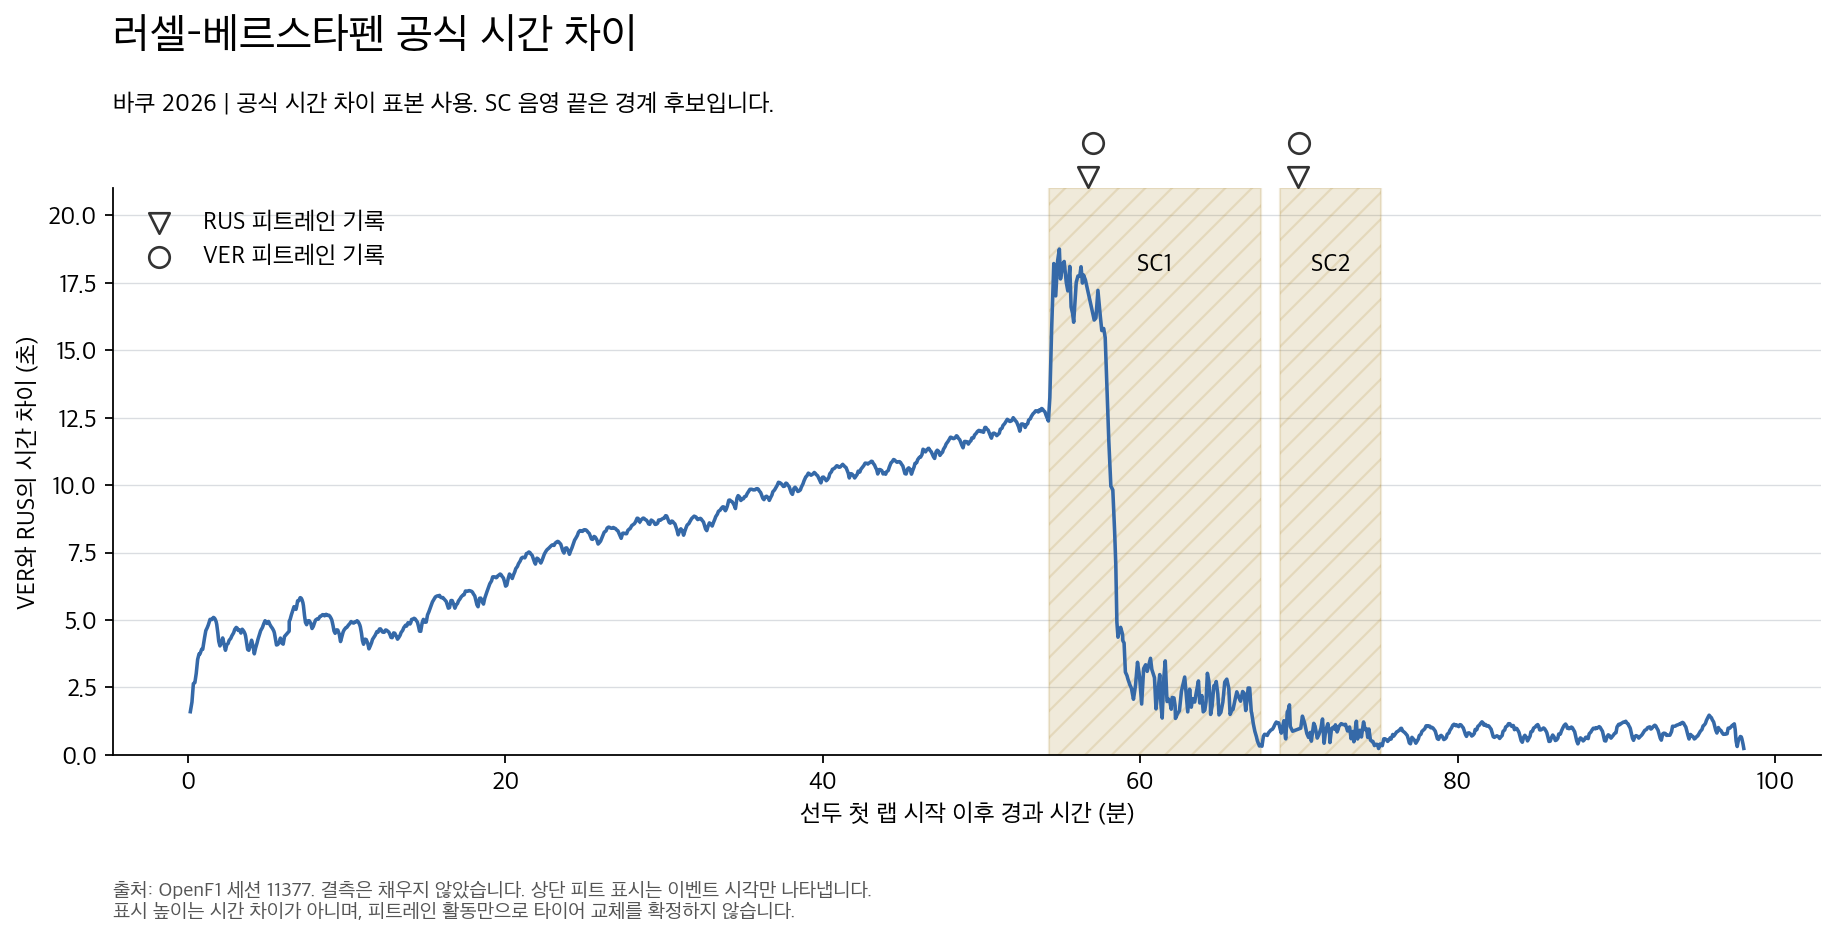

In [17]:
from IPython.display import Image,display
display(Image(filename=str(out/'01_race_context.png')))

### 비교 후보 랩에서 누가 더 빨랐을까요?

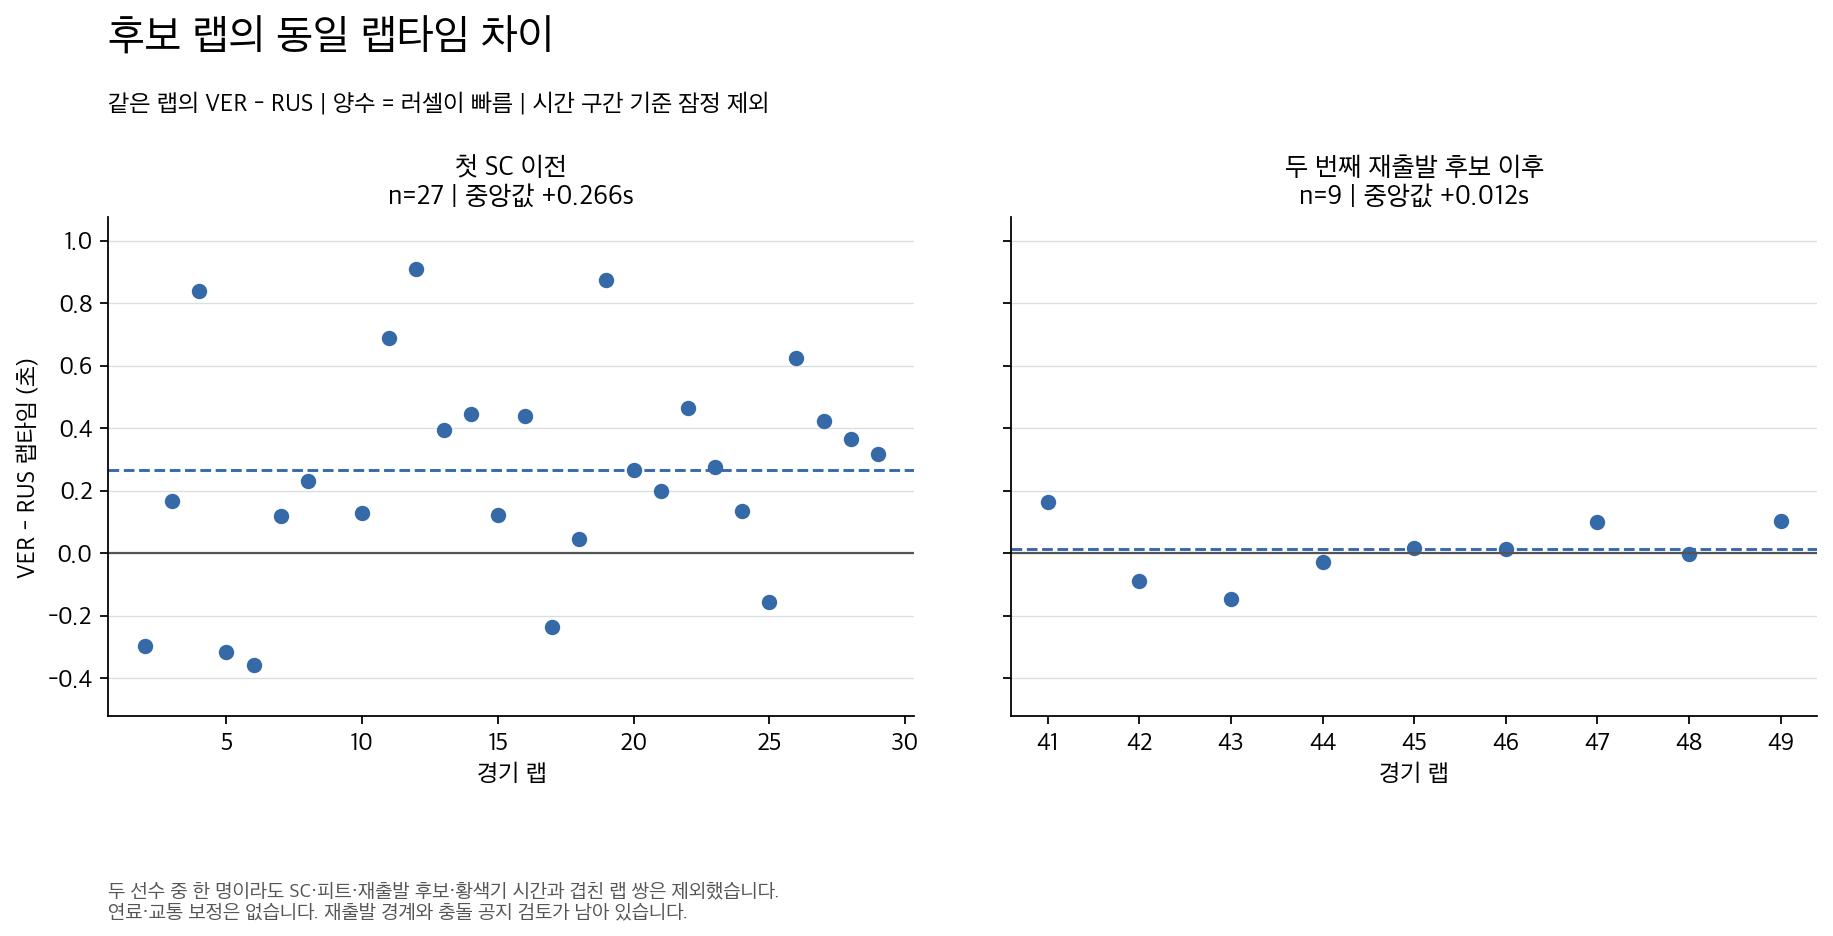

In [18]:
from IPython.display import Image,display
display(Image(filename=str(out/'02_candidate_paired_pace.png')))

### 어떤 타이어 맥락이 남아 있나요?

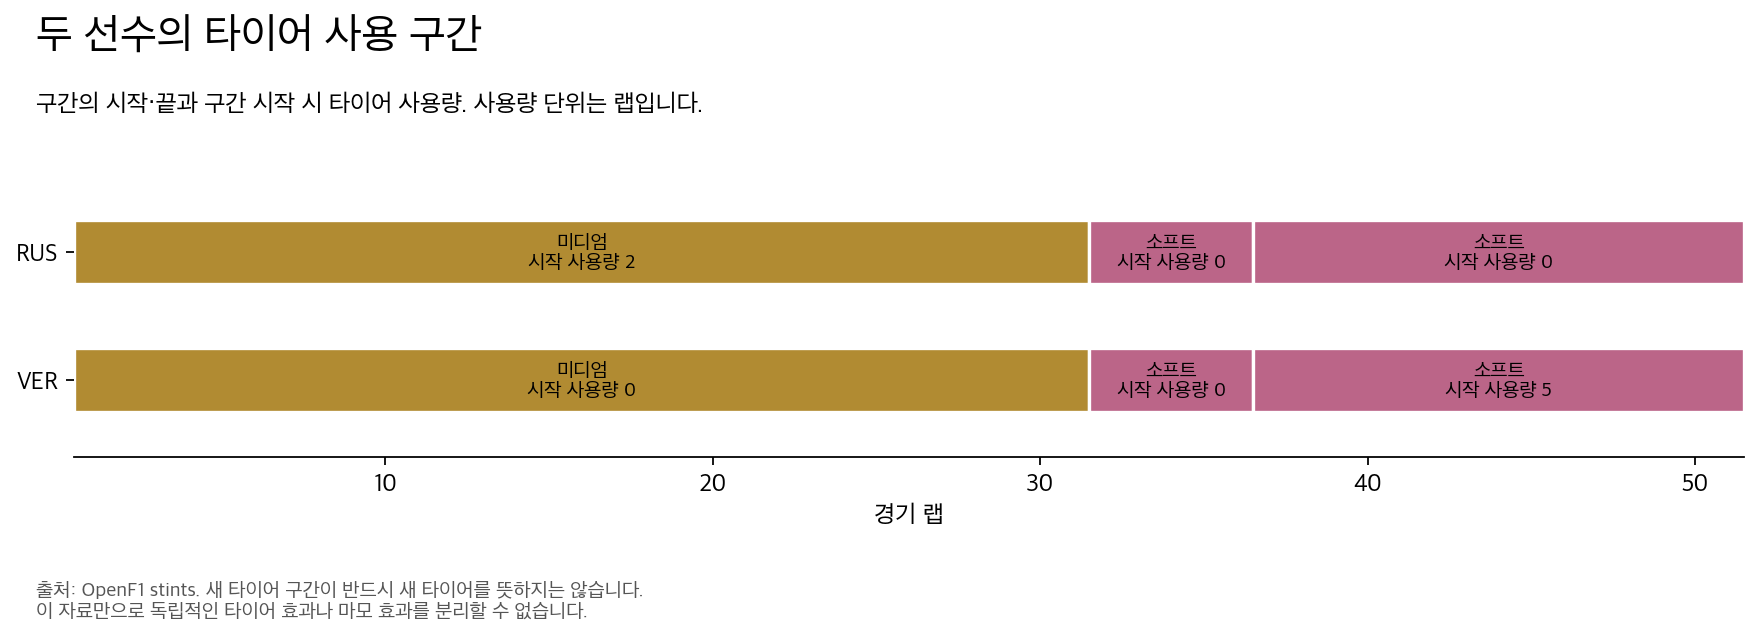

In [19]:
from IPython.display import Image,display
display(Image(filename=str(out/'03_tyre_context.png')))

## 검증

랩마다 두 선수가 한 번씩 연결되고 차이를 다시 계산할 수 있는지, 원본 바이트가 변경되지 않았는지 확인합니다.

In [20]:
assert len(paired)==51 and not paired.lap_number.duplicated().any()
assert np.allclose(paired.delta_VER_minus_RUS_seconds,paired.lap_duration_VER-paired.lap_duration_RUS)
for item in audit['sources']:
    assert hashlib.sha256((ROOT/item['file']).read_bytes()).hexdigest()==item['sha256']
print('PASS: pair keys, difference formula, raw hashes')

PASS: pair keys, difference formula, raw hashes


## 다음 단계

최종 페이스 결론을 쓰기 전 재출발 후보와 운영 공지 충돌을 검토하세요. 제외 표를 읽고 어떤 랩을 비교했는지 설명하세요. 중앙값·IQR은 선정된 랩의 기술통계이며 타이어 인과 효과나 가상의 우승자를 뜻하지 않습니다.